# Backtest Snowball with `CSVDataSource`

This notebook backtests snowball against historical data in `data/quotes/`.

In [1]:
from collections.abc import Iterable
from pathlib import Path

import matplotlib.dates as mdates
import pandas as pd
from core import (
    BacktestTaskDefinition,
    CSVDataSource,
    CSVTickSchema,
    CurrencyPair,
    EventBus,
    InMemoryTaskRepository,
    LogLevel,
    RecordingEventHandler,
    StrategyEvent,
    StrategyParameters,
    TaskManager,
    Tick,
    TickGranularity,
    TickGranularityFilter,
    configure_logging,
)
from IPython.display import display
from snowball import SnowballStrategy

configure_logging(level=LogLevel.WARNING)

<Logger core (WARNING)>

## 1. Point the data source at the quote archives

`CSVDataSource` streams the daily `*.csv.gz` archives lazily and filters rows by ticker before validating them. For an interactive Snowball smoke test, this notebook uses the first archive, samples one tick per minute, and caps the replay after a fixed number of sampled ticks. Increase `ARCHIVE_LIMIT`, lower `SAMPLE_GRANULARITY`, or raise `TICK_LIMIT` for a deeper run.


In [2]:
INSTRUMENT = CurrencyPair.of("EUR_USD")
QUOTES_DIR = Path("data") / "quotes"
ARCHIVE_LIMIT = 1
SAMPLE_GRANULARITY = TickGranularity.TICK
TICK_LIMIT = 100000

quote_paths = sorted(QUOTES_DIR.glob("*.csv.gz"))
selected_quote_paths = quote_paths[:ARCHIVE_LIMIT]
if not selected_quote_paths:
    raise FileNotFoundError(f"no quote archives found in {QUOTES_DIR}")

raw_data_source = CSVDataSource(
    tick_paths=selected_quote_paths,
    tick_schema=CSVTickSchema.polygon_forex_quotes(),
)


class TickLimitFilter:
    def __init__(self, limit: int) -> None:
        self.limit = limit

    def filter_ticks(self, ticks: Iterable[Tick]) -> Iterable[Tick]:
        for index, tick in enumerate(ticks):
            if index >= self.limit:
                break
            yield tick

    def filter_candles(self, candles):
        return candles


data_source = raw_data_source.with_filters(
    TickGranularityFilter.of(SAMPLE_GRANULARITY),
    TickLimitFilter(TICK_LIMIT),
)

print(f"Streaming {INSTRUMENT} from {len(selected_quote_paths)} archive(s):")
for archive in selected_quote_paths:
    print(f"  {archive.name}")
print(f"Sampling: {SAMPLE_GRANULARITY.value}; limit: {TICK_LIMIT:,} sampled ticks")

Streaming EUR_USD from 1 archive(s):
  2026-06-23.csv.gz
Sampling: tick; limit: 100,000 sampled ticks


In [3]:
# Derive the backtest window from the selected archive filenames
# (YYYY-MM-DD per day) instead of scanning the data.
from datetime import UTC, datetime, timedelta

archive_days = sorted(
    datetime.strptime(path.name.split(".", 1)[0], "%Y-%m-%d").replace(tzinfo=UTC)
    for path in selected_quote_paths
)
start_at = archive_days[0]
end_at = archive_days[-1] + timedelta(days=1)
print(f"Backtest window: {start_at} -> {end_at}")

Backtest window: 2026-06-23 00:00:00+00:00 -> 2026-06-24 00:00:00+00:00


## 2. Define the Snowball backtest

The task definition still describes only the instrument, time window, and parameters. The concrete strategy instance is supplied directly to `TaskManager.start_backtest`. This configuration keeps the run single-directional (`hedging_enabled=False`) so the resulting slot lifecycle is easy to inspect, while enabling stop-loss and rebuild behavior.


In [4]:
parameters = SnowballStrategy.normalize_parameters(
    StrategyParameters.of(
        cycle={"hedging_enabled": False},
        forward={"take_profit_pips": "20"},
        sizing={"base_units": "1000"},
        grid={
            "max_retracements_per_layer": 3,
            "max_layers": 2,
            "refill": {"enabled": True, "max_reusable_retracement": 1},
        },
        counter={
            "interval": {
                "mode": "constant",
                "head_pips": "10",
                "tail_pips": "10",
                "flat_steps": 0,
            }
        },
        stop_loss={"enabled": True, "mode": "auto"},
        rebuild={"enabled": True},
        protection={"emergency_enabled": False, "shrink_enabled": False},
    )
)

definition = BacktestTaskDefinition(
    name=f"{INSTRUMENT} Snowball smoke test",
    instrument=INSTRUMENT,
    start_at=start_at,
    end_at=end_at,
    parameters=parameters,
)
definition.dump()

{'id': UUID('019f4d2f-e85c-70f8-9cca-8fc83635406c'),
 'name': 'EUR_USD Snowball smoke test',
 'instrument': {'base': {'code': 'EUR'}, 'quote': {'code': 'USD'}},
 'parameters': {'values': {'sizing': {'base_units': Decimal('1000'),
    'initial_entry_units_multiplier': Decimal('1'),
    'additional_layer_base_units_multiplier': Decimal('1')},
   'grid': {'max_retracements_per_layer': 3,
    'max_layers': 2,
    'refill': {'enabled': True, 'max_reusable_retracement': 1}},
   'cycle': {'take_profit_pips': Decimal('20'),
    'hedging_enabled': False,
    'reseed_when_all_positions_pending_rebuild': False},
   'counter': {'interval': {'mode': 'constant',
     'head_pips': Decimal('10'),
     'tail_pips': Decimal('10'),
     'flat_steps': 0,
     'gamma': Decimal('1.4'),
     'manual_pips': []},
    'take_profit': {'mode': 'weighted_avg',
     'fixed_pips': Decimal('5'),
     'step_pips': Decimal('1'),
     'multiplier': Decimal('1.2')}},
   'stop_loss': {'enabled': True,
    'mode': 'auto',


In [5]:
strategy = SnowballStrategy(
    name="snowball",
    parameters=definition.parameters,
)
strategy.config.to_dict()

{'sizing': {'base_units': Decimal('1000'),
  'initial_entry_units_multiplier': Decimal('1'),
  'additional_layer_base_units_multiplier': Decimal('1')},
 'grid': {'max_retracements_per_layer': 3,
  'max_layers': 2,
  'refill': {'enabled': True, 'max_reusable_retracement': 1}},
 'cycle': {'take_profit_pips': Decimal('20'),
  'hedging_enabled': False,
  'reseed_when_all_positions_pending_rebuild': False},
 'counter': {'interval': {'mode': 'constant',
   'head_pips': Decimal('10'),
   'tail_pips': Decimal('10'),
   'flat_steps': 0,
   'gamma': Decimal('1.4'),
   'manual_pips': []},
  'take_profit': {'mode': 'weighted_avg',
   'fixed_pips': Decimal('5'),
   'step_pips': Decimal('1'),
   'multiplier': Decimal('1.2')}},
 'stop_loss': {'enabled': True,
  'mode': 'auto',
  'distance': {'mode': 'constant',
   'head_pips': Decimal('50'),
   'tail_pips': Decimal('20'),
   'flat_steps': 0,
   'gamma': Decimal('1.4'),
   'manual_pips': []},
  'protect_highest_retracement': {'enabled': False, 'from_r

## 3. Run the backtest

`TaskManager.start_backtest` launches a `BacktestRunner` on a background thread. Because no broker is supplied, Core uses dry-run execution and returns filled orders immediately. That is useful here: Snowball receives execution reports, so requested entries become filled entries and closes can advance through the lifecycle.


In [6]:
recorder = RecordingEventHandler()
event_bus = EventBus(handlers=[recorder])
manager = TaskManager(repository=InMemoryTaskRepository(), event_bus=event_bus)

run = manager.start_backtest(definition, data_source=data_source, strategy=strategy)
final_task = run.wait(timeout=600)
manager.shutdown()

print(f"Task {final_task.id} finished with status: {final_task.status.value}")
print(f"Events recorded: {len(recorder.events)}")

Task 019f4d2f-e86b-76ea-8af5-0a38ec32e25e finished with status: completed
Events recorded: 35


## 4. Inspect Snowball events

Snowball maps its domain events into Core strategy events. The metadata columns below expose the slot identity and lifecycle context: cycle, direction, layer, slot, build number, entry role, close reason, planned TP/SL, planned rebuild price, rebuild flag, and realized P/L where available.


In [ ]:
signals = [event for event in recorder.events if isinstance(event, StrategyEvent)]


def meta(event: StrategyEvent, key: str):
    return event.metadata.get(key)


signals_df = pd.DataFrame(
    {
        "timestamp": event.timestamp,
        "action": event.action.value,
        "display_id": event.display_id,
        "side": event.side.value if event.side else None,
        "units": float(event.units) if event.units is not None else None,
        "price": float(event.price.amount) if event.price is not None else None,
        "decision": event.reason.code.value,
        "rule": event.reason.rule_id,
        "snowball_event": meta(event, "snowball_event"),
        "cycle_id": meta(event, "cycle_id"),
        "direction": meta(event, "direction"),
        "entry_role": meta(event, "entry_role"),
        "layer_number": meta(event, "layer_number"),
        "slot_number": meta(event, "slot_number"),
        "build_number": meta(event, "build_number"),
        "close_reason": meta(event, "close_reason"),
        "is_rebuild": meta(event, "is_rebuild"),
        "planned_entry_price": meta(event, "planned_entry_price"),
        "filled_entry_price": meta(event, "filled_entry_price"),
        "planned_take_profit_price": meta(event, "planned_take_profit_price"),
        "filled_take_profit_price": meta(event, "filled_take_profit_price"),
        "planned_stop_loss_price": meta(event, "planned_stop_loss_price"),
        "filled_stop_loss_price": meta(event, "filled_stop_loss_price"),
        "planned_rebuild_price": meta(event, "planned_rebuild_price"),
        "filled_rebuild_price": meta(event, "filled_rebuild_price"),
        "realized_pl": meta(event, "realized_pl"),
    }
    for event in signals
)
print(f"{len(signals_df)} strategy events")
signals_df

11 strategy events


,timestamp,action,display_id,side,units,price,decision,rule,snowball_event,cycle_id,...,is_rebuild,planned_entry_price,filled_entry_price,planned_take_profit_price,planned_stop_loss_price,planned_rebuild_price,filled_take_profit_price,filled_stop_loss_price,filled_rebuild_price,realized_pl
0,2026-06-23 00:00:00+00:00,open_trade,L1R0B1,buy,1000.0,1.14273,entry_signal,snowball.open,open,1,...,False,1.14273 USD,1.14273 USD,1.14473 USD,1.14173 USD,NaN,NaN,NaN,NaN,NaN
1,2026-06-23 05:00:41+00:00,close_trade,L1R0B1,sell,1000.0,1.14170,exit_signal,snowball.close.stop_loss,close,1,...,False,1.14273 USD,1.14273 USD,1.14473 USD,1.14173 USD,1.14173 USD,NaN,1.1417 USD,NaN,-1.03000 USD
2,2026-06-23 05:00:42+00:00,open_trade,L1R0B2,buy,1000.0,1.14173,entry_signal,snowball.open.rebuild,open,1,...,True,1.14173 USD,1.14173 USD,1.14373 USD,1.14073 USD,1.14173 USD,NaN,NaN,1.14173 USD,NaN
3,2026-06-23 07:20:16+00:00,close_trade,L1R0B2,sell,1000.0,1.14375,exit_signal,snowball.close.take_profit,close,1,...,False,1.14173 USD,1.14173 USD,1.14373 USD,1.14073 USD,NaN,1.14375 USD,NaN,NaN,2.02000 USD
4,2026-06-23 07:20:16+00:00,open_trade,L1R0B1,buy,1000.0,1.14380,entry_signal,snowball.open,open,2,...,False,1.1438 USD,1.1438 USD,1.1458 USD,1.1428 USD,NaN,NaN,NaN,NaN,NaN
5,2026-06-23 07:31:39+00:00,close_trade,L1R0B1,sell,1000.0,1.14280,exit_signal,snowball.close.stop_loss,close,2,...,False,1.1438 USD,1.1438 USD,1.1458 USD,1.1428 USD,1.1428 USD,NaN,1.1428 USD,NaN,-1.0000 USD
6,2026-06-23 07:31:40+00:00,open_trade,L1R0B2,buy,1000.0,1.14280,entry_signal,snowball.open.rebuild,open,2,...,True,1.1428 USD,1.1428 USD,1.1448 USD,1.1418 USD,1.1428 USD,NaN,NaN,1.1428 USD,NaN
7,2026-06-23 07:41:03+00:00,close_trade,L1R0B2,sell,1000.0,1.14180,exit_signal,snowball.close.stop_loss,close,2,...,False,1.1428 USD,1.1428 USD,1.1448 USD,1.1418 USD,1.1418 USD,NaN,1.1418 USD,NaN,-1.0000 USD
8,2026-06-23 07:41:04+00:00,open_trade,L1R0B3,buy,1000.0,1.14180,entry_signal,snowball.open.rebuild,open,2,...,True,1.1418 USD,1.1418 USD,1.1438 USD,1.1408 USD,1.1418 USD,NaN,NaN,1.1418 USD,NaN
9,2026-06-23 07:53:44+00:00,close_trade,L1R0B3,sell,1000.0,1.14080,exit_signal,snowball.close.stop_loss,close,2,...,False,1.1418 USD,1.1418 USD,1.1438 USD,1.1408 USD,1.1408 USD,NaN,1.1408 USD,NaN,-1.0000 USD


In [8]:
if signals_df.empty:
    print("no Snowball events")
else:
    display(signals_df["action"].value_counts().rename("count"))
    display(
        pd.crosstab(
            signals_df["snowball_event"],
            signals_df["entry_role"].fillna("n/a"),
            dropna=False,
        )
    )
    display(signals_df["close_reason"].dropna().value_counts().rename("count"))

action
open_trade     6
close_trade    5
Name: count, dtype: int64

entry_role,initial
snowball_event,
close,5
open,6


close_reason
stop_loss      4
take_profit    1
Name: count, dtype: int64

<Axes: title={'center': 'EUR_USD Snowball signal prices'}, xlabel='time', ylabel='price (USD)'>

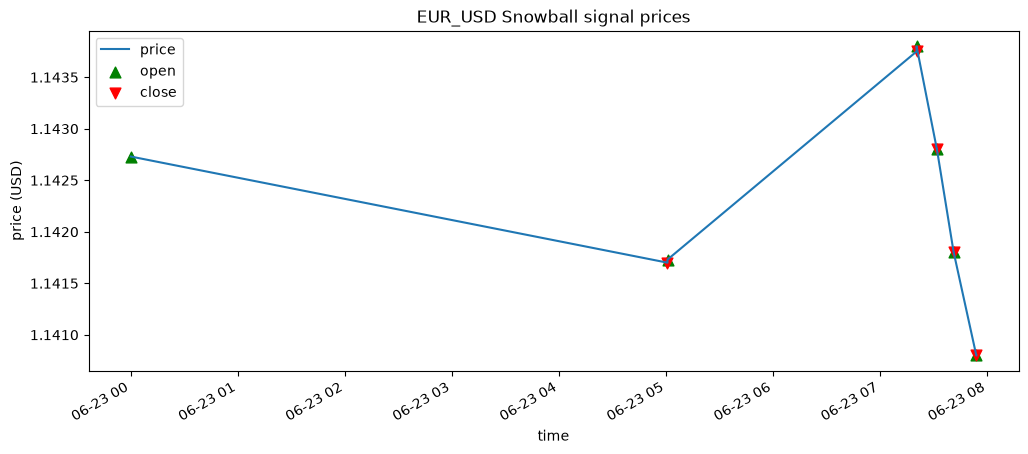

In [9]:
def plot_signals(signals: pd.DataFrame):
    """Plot recorded Snowball signal prices with open/close markers."""
    plotted = signals[signals["price"].notna()].copy()
    if plotted.empty:
        print("no priced signals to plot")
        return None

    times = pd.to_datetime(plotted["timestamp"]).dt.tz_localize(None)
    marker_times = mdates.date2num(times)
    opens = (plotted["action"] == "open_trade").to_numpy()
    closes = (plotted["action"] == "close_trade").to_numpy()
    prices = plotted["price"].to_numpy()

    ax = plotted.assign(t=times).plot(
        x="t",
        y="price",
        figsize=(12, 5),
        legend=False,
        title=f"{INSTRUMENT} Snowball signal prices",
    )
    ax.scatter(marker_times[opens], prices[opens], marker="^", color="green", s=60, label="open")
    ax.scatter(marker_times[closes], prices[closes], marker="v", color="red", s=60, label="close")
    ax.set_xlabel("time")
    ax.set_ylabel(f"price ({INSTRUMENT.quote})")
    ax.legend()
    return ax


plot_signals(signals_df)

## Next steps

- Increase `TICK_LIMIT` or `ARCHIVE_LIMIT` for longer Snowball lifecycle coverage.
- Set `cycle={"hedging_enabled": True}` to test long and short cycles together.
- Tune `counter.interval`, `stop_loss`, and `rebuild` parameters in the task definition to exercise specific slot transitions.
- Change `INSTRUMENT` to another pair available in the same Polygon quote archives.
